In [1]:
# Importamos librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import itertools

from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

In [2]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler 
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

In [3]:
data = pd.read_csv("Medical Cost Personal.csv")
print(f"shape: {data.shape}")
data.head()

shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df = pd.DataFrame(data)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
for col in df:
    print(f"{col}: {df[col].nunique()}")

age: 47
sex: 2
bmi: 548
children: 6
smoker: 2
region: 4
charges: 1337


In [7]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [8]:
df.describe(include=[object]).T

,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


## Analisis exploratorio de Datos (EDA)

In [11]:
df["sex"] = df["sex"].map({"male": 0, "female": 1})

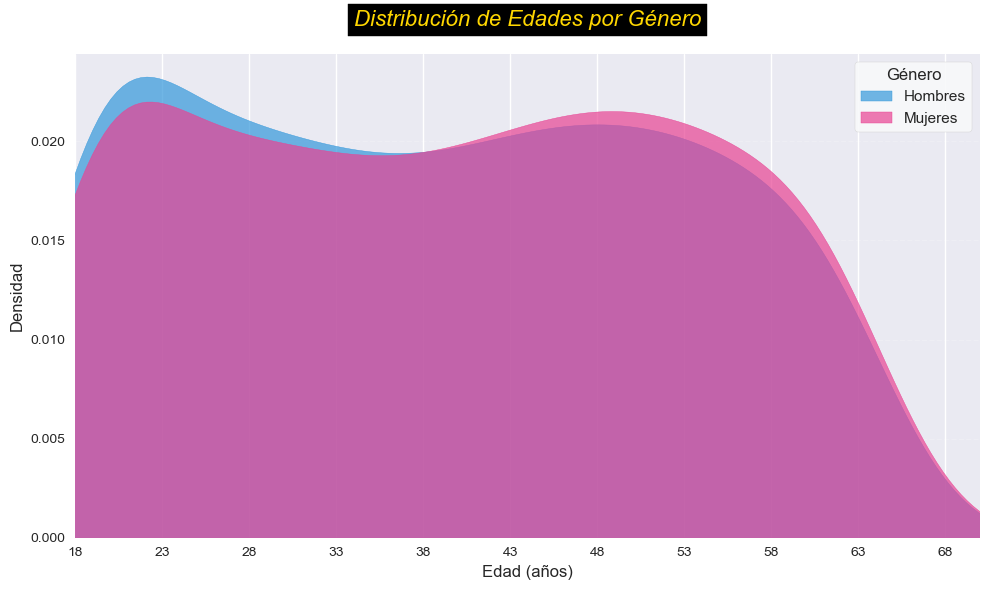

In [12]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración
warnings.filterwarnings("ignore", category=FutureWarning)
font = {
    "fontsize": 16,
    "fontstyle": "italic",
    "backgroundcolor": "black",
    "color": "gold"  # Cambié a oro para mejor contraste
}
plt.style.use("seaborn-v0_8")  # Estilo moderno equivalente a seaborn-notebook

# Crear figura
plt.figure(figsize=(10, 6))

# KDE para hombres (sex=0)
sns.kdeplot(df.loc[df["sex"] == 0, "age"], 
            label="Hombres", 
            fill=True,
            color="#3498db",  # Azul
            alpha=0.7)

# KDE para mujeres (sex=1)
sns.kdeplot(df.loc[df["sex"] == 1, "age"], 
            label="Mujeres", 
            fill=True,
            color="#e84393",  # Rosa
            alpha=0.7)

# Personalización
plt.title("Distribución de Edades por Género", 
          fontdict=font, 
          pad=20)
plt.xlabel("Edad (años)", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.xticks(np.arange(18, 70, 5))  # Rango típico de edades médicas
plt.xlim([18, 70])  # Edades mínimas/máximas relevantes
plt.grid(axis='y', alpha=0.2, linestyle='--')

# Leyenda mejorada
legend = plt.legend(title="Género", 
                   title_fontsize=12,
                   fontsize=11,
                   frameon=True,
                   framealpha=0.9)
legend.get_frame().set_facecolor('#f8f9fa')  # Fondo blanco semi-transparente

plt.tight_layout()
plt.show()

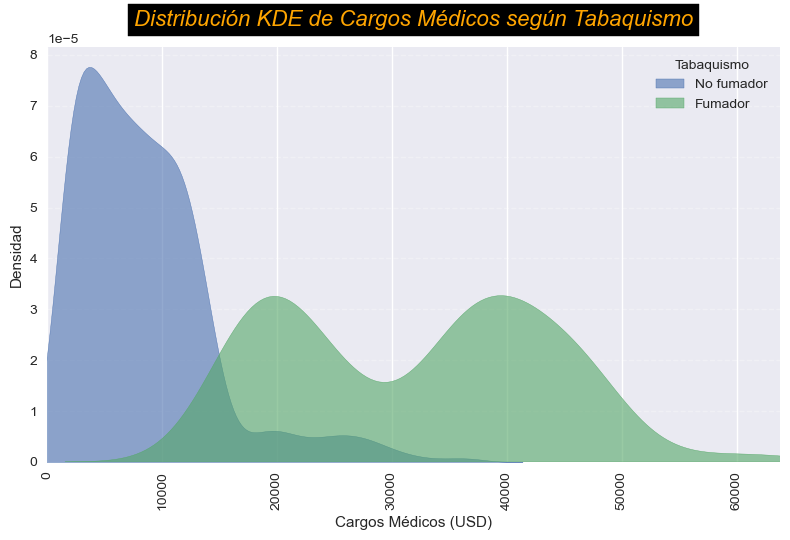

In [14]:
import warnings

# Configuración
%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)

# Estilo de fuente
font = {
    "fontsize": 16,
    "fontstyle": "italic",
    "backgroundcolor": "black",
    "color": "orange"
}

# KDE plot con tu dataset
sns.kdeplot(df.loc[df["smoker"] == "no", "charges"], label="No fumador", fill=True, alpha=0.6)
sns.kdeplot(df.loc[df["smoker"] == "yes", "charges"], label="Fumador", fill=True, alpha=0.6)

# Personalización
plt.title("Distribución KDE de Cargos Médicos según Tabaquismo", fontdict=font, pad=15)
plt.xticks(np.arange(0, df["charges"].max(), 10000), rotation=90)
plt.xlim([0, df["charges"].max()])
plt.xlabel("Cargos Médicos (USD)")
plt.ylabel("Densidad")
plt.legend(title="Tabaquismo")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

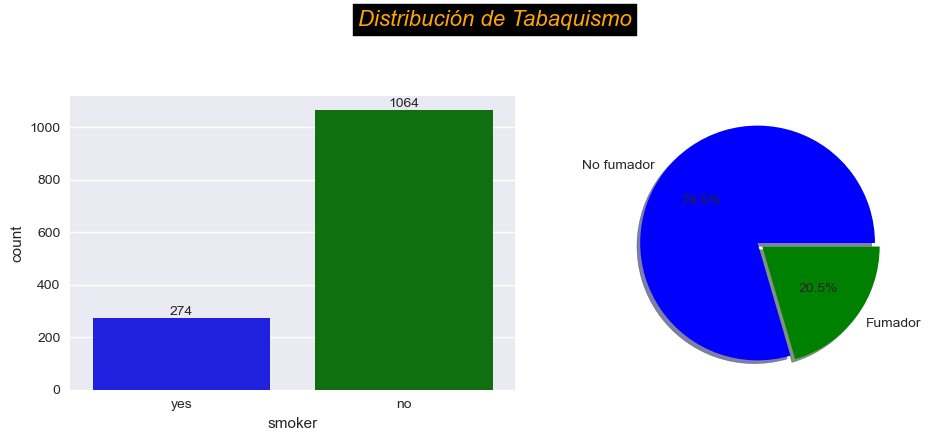

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Crear subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteo de fumadores y no fumadores
sns.countplot(data=df, x="smoker", ax=axes[0], palette=["blue", "green"])
for container in axes[0].containers:
    axes[0].bar_label(container)

# Gráfico de pastel
slices = df["smoker"].value_counts().values
labels = ["No fumador", "Fumador"]
axes[1].pie(slices, 
            labels=labels, 
            colors=["blue", "green"], 
            shadow=True, 
            explode=[0, 0.05], 
            autopct="%1.1f%%")

# Título
font = {
    "fontsize": 16,
    "fontstyle": "italic",
    "backgroundcolor": "black",
    "color": "orange"
}
plt.suptitle("Distribución de Tabaquismo", y=1.09, **font)
plt.tight_layout()
plt.show()

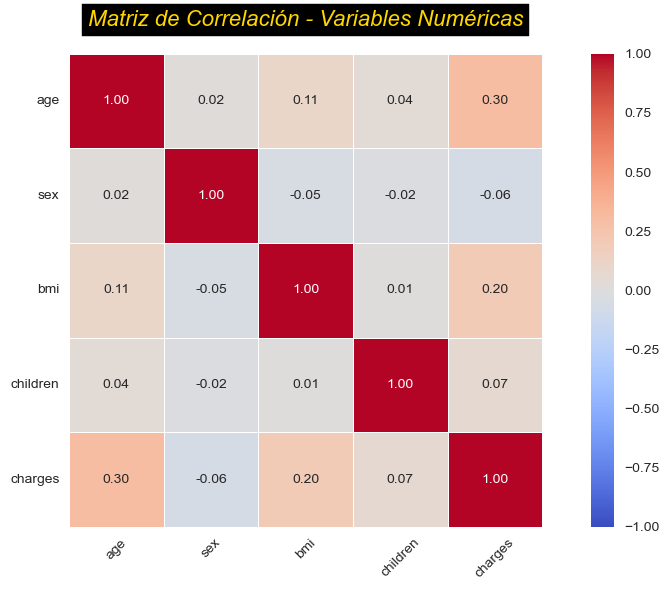

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Seleccionar solo las columnas numéricas para la correlación
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calcular la matriz de correlación
correlation_matrix = numeric_df.corr()

# Configuración del gráfico
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm", 
            vmin=-1, vmax=1, 
            linewidths=0.5, 
            linecolor="white",
            square=True)

plt.title("Matriz de Correlación - Variables Numéricas", fontsize=16, fontstyle="italic", backgroundcolor="black", color="gold", pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

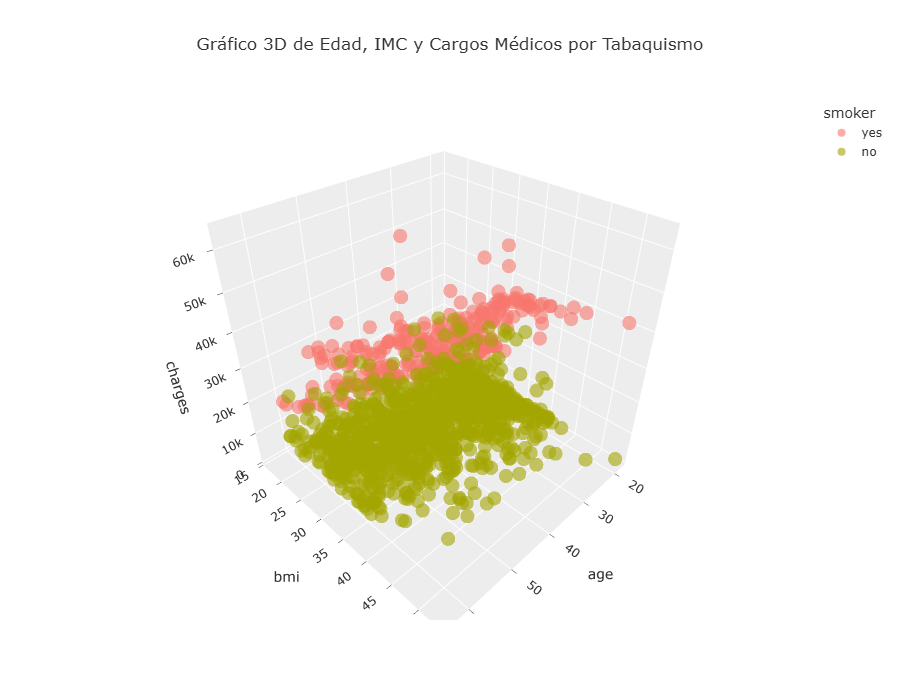

In [17]:
import plotly.express as px
import plotly.io as pio

# Mapeamos "sex" y/o "smoker" si quieres valores numéricos en z
# Pero podemos dejar "charges" como z directamente

fig = px.scatter_3d(
    data_frame=df,
    x="age",
    y="bmi",
    z="charges",
    color="smoker",  # Podrías usar también "sex"
    opacity=0.6,
    template="ggplot2",
    height=700,
    title="Gráfico 3D de Edad, IMC y Cargos Médicos por Tabaquismo"
)

pio.show(fig)